In [1]:
!pip install pennylane --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 37.6 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [2]:
import pennylane as qml
from pennylane import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

print("PennyLane version:", qml.__version__)


PennyLane version: 0.45.1


In [4]:
# Exact diagonalization: 2-qubit Heisenberg Hamiltonian
J = 1.0

H = (
    J * (qml.PauliX(0) @ qml.PauliX(1))
    + J * (qml.PauliY(0) @ qml.PauliY(1))
    + J * (qml.PauliZ(0) @ qml.PauliZ(1))
)

H_matrix = qml.matrix(H)

eigvals, eigvecs = np.linalg.eigh(H_matrix)
ground_state = eigvecs[:, 0]
print("Exact Diagonalization")
print("Eigenvalues:", eigvals)
print("Exact ground-state energy:", eigvals[0])
print("Ground state:", ground_state)

t = np.pi / 4
U = expm(-1j * H_matrix * t)

print("\nEvolution operator U = exp(-i H t), t = pi/4")
print(U)


Exact Diagonalization
Eigenvalues: [-3.  1.  1.  1.]
Exact ground-state energy: -3.0
Ground state: [ 0.        +0.j  0.70710678+0.j -0.70710678+0.j  0.        +0.j]

Evolution operator U = exp(-i H t), t = pi/4
[[7.07106781e-01-7.07106781e-01j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 2.22044605e-16+0.00000000e+00j
  7.07106781e-01-7.07106781e-01j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 7.07106781e-01-7.07106781e-01j
  1.11022302e-16+1.11022302e-16j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j 7.07106781e-01-7.07106781e-01j]]


In [6]:
# Ideal IQPE
ideal_dev = qml.device("default.qubit", wires=3)
shots = 1000
n_bits = 4
@qml.set_shots(shots)
@qml.qnode(ideal_dev)
def ideal_iqpe():
    qml.StatePrep(ground_state, wires=[1, 2])

    base = qml.QubitUnitary(U, wires=[1, 2])

    bits = qml.iterative_qpe(
        base,
        aux_wire=0,
        iters=n_bits
    )

    return qml.sample(bits)

ideal_results = ideal_iqpe()
ideal_bits = np.round(ideal_results.mean(axis=0)).astype(int)

ideal_phase = sum(
    int(bit) / (2 ** (i + 1))
    for i, bit in enumerate(ideal_bits)
)

ideal_energy = -(2 * np.pi * ideal_phase) / t
print("IDEAL IQPE")
print("Majority bits:", ideal_bits)
print("Estimated phase:", ideal_phase)
print("Recovered energy:", ideal_energy)
print("Exact energy:", eigvals[0])
print("Absolute error:", abs(ideal_energy - eigvals[0]))


IDEAL IQPE
Majority bits: [0 1 1 0]
Estimated phase: 0.375
Recovered energy: -3.0
Exact energy: -3.0
Absolute error: 0.0


In [7]:
def controlled_unitary(U):
    CU = np.eye(8, dtype=complex)
    CU[4:8, 4:8] = U
    return CU

CU = controlled_unitary(U)

print("Controlled-U shape:", CU.shape)


Controlled-U shape: (8, 8)


In [9]:
# Noisy single IQPE iteration
def add_depolarizing_noise(p):
    """Apply independent single-qubit depolarizing noise to all 3 wires."""
    if p <= 0:
        return

    for w in range(3):
        qml.DepolarizingChannel(p, wires=w)


def noisy_iqpe_step(U_power, feedback, p_depol=0.0, p_readout=0.0,
                    shots=1000):
    """
    Execute one IQPE iteration.

    p_depol   : depolarizing probability inserted after major operations
    p_readout : classical probability of flipping the measured ancilla bit
    shots     : number of repetitions
    """

    dev = qml.device("default.mixed", wires=3, shots=shots)

    CU_power = controlled_unitary(U_power)

    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(ground_state, wires=[1, 2])
        add_depolarizing_noise(p_depol)
        qml.Hadamard(0)
        add_depolarizing_noise(p_depol)
        qml.QubitUnitary(CU_power, wires=[0, 1, 2])
        add_depolarizing_noise(p_depol)
        qml.RZ(feedback, wires=0)
        add_depolarizing_noise(p_depol)
        qml.Hadamard(0)
        add_depolarizing_noise(p_depol)

        return qml.sample(wires=0)

    samples = np.asarray(circuit()).reshape(-1)

    # Classical readout error
    if p_readout > 0:
        rng = np.random.default_rng()
        flips = rng.random(len(samples)) < p_readout
        samples = np.logical_xor(samples.astype(int), flips).astype(int)

    probability_one = float(np.mean(samples))
    bit = int(probability_one >= 0.5)

    return bit, probability_one, samples


In [10]:
# noisy IQPE
def run_noisy_iqpe(p_depol=0.0, p_readout=0.0, shots=1000, n_bits=4,
                   verbose=True):
    """
    Run the complete adaptive IQPE algorithm.

    The iteration order follows the verified notebook:
    k = n_bits-1, ..., 0.
    """

    bits = []
    probabilities = []
    feedback = 0.0

    for k in reversed(range(n_bits)):
        U_power = np.linalg.matrix_power(U, 2 ** k)

        bit, p1, _ = noisy_iqpe_step(
            U_power,
            feedback,
            p_depol=p_depol,
            p_readout=p_readout,
            shots=shots
        )

        bits.append(bit)
        probabilities.append(p1)

        feedback = -np.pi * sum(
            bits[j] / (2 ** (j + 1))
            for j in range(len(bits))
        )

        if verbose:
            print(
                f"Iteration k={k}: bit={bit}, "
                f"P(1)={p1:.4f}, feedback={feedback:.6f}"
            )

    phase = sum(
        bit / (2 ** (i + 1))
        for i, bit in enumerate(bits)
    )

    energy = -(2 * np.pi * phase) / t
    error = abs(energy - eigvals[0])

    return {
        "bits": np.array(bits),
        "probabilities": np.array(probabilities),
        "phase": phase,
        "energy": energy,
        "error": error
    }


In [11]:
noisy_zero = run_noisy_iqpe(
    p_depol=0.0,
    p_readout=0.0,
    shots=1000,
    n_bits=4,
    verbose=True
)

print("\n" + "=" * 60)
print("NOISE-FREE MANUAL IQPE CHECK")
print("=" * 60)
print("Bits:", noisy_zero["bits"])
print("Phase:", noisy_zero["phase"])
print("Energy:", noisy_zero["energy"])
print("Absolute error:", noisy_zero["error"])


Iteration k=3: bit=0, P(1)=0.0000, feedback=-0.000000
Iteration k=2: bit=1, P(1)=1.0000, feedback=-0.785398
Iteration k=1: bit=1, P(1)=0.8330, feedback=-1.178097
Iteration k=0: bit=0, P(1)=0.2880, feedback=-1.178097

NOISE-FREE MANUAL IQPE CHECK
Bits: [0 1 1 0]
Phase: 0.375
Energy: -3.0
Absolute error: 0.0


/usr/local/lib/python3.13/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [12]:
# Depolarizing-noise sweep
noise_levels = np.array([
    0.000,
    0.001,
    0.0025,
    0.005,
    0.010,
    0.020,
    0.050,
    0.100
])

sweep_shots = 2000

energies = []
errors = []
phases = []
all_bits = []

for p in noise_levels:
    result = run_noisy_iqpe(
        p_depol=float(p),
        p_readout=0.0,
        shots=sweep_shots,
        n_bits=4,
        verbose=False
    )

    energies.append(result["energy"])
    errors.append(result["error"])
    phases.append(result["phase"])
    all_bits.append(result["bits"])

    print(
        f"p={p:7.4f} | "
        f"bits={result['bits']} | "
        f"phase={result['phase']:.5f} | "
        f"energy={result['energy']:.5f} | "
        f"error={result['error']:.5f}"
    )

energies = np.asarray(energies)
errors = np.asarray(errors)
phases = np.asarray(phases)


p= 0.0000 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.0010 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.0025 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.0050 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.0100 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.0200 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.0500 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000
p= 0.1000 | bits=[0 1 1 0] | phase=0.37500 | energy=-3.00000 | error=0.00000


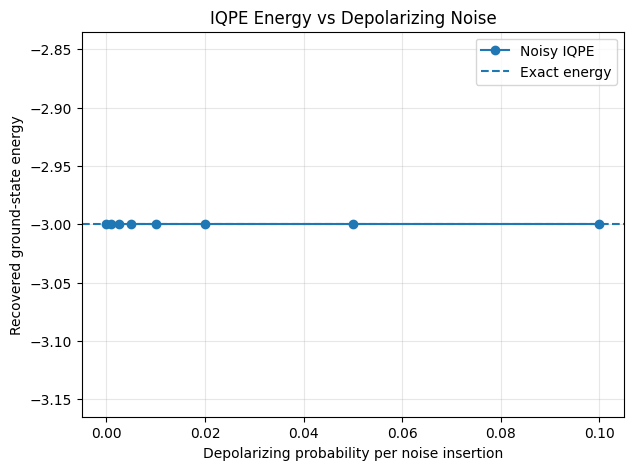

In [13]:
# Plot: recovered energy vs depolarizing noise
plt.figure(figsize=(7, 5))
plt.plot(noise_levels, energies, marker="o", label="Noisy IQPE")
plt.axhline(float(eigvals[0]), linestyle="--", label="Exact energy")
plt.xlabel("Depolarizing probability per noise insertion")
plt.ylabel("Recovered ground-state energy")
plt.title("IQPE Energy vs Depolarizing Noise")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


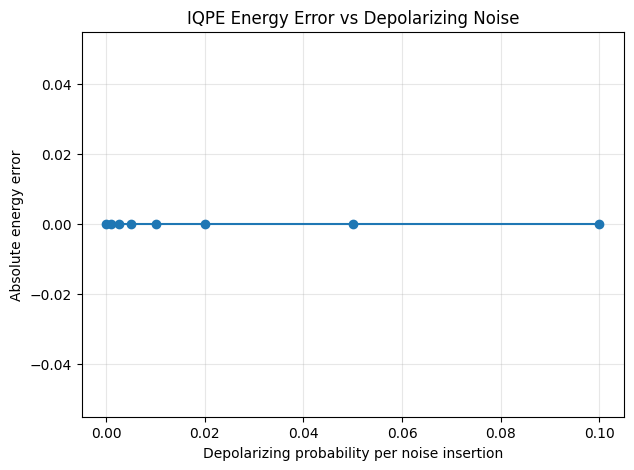

In [14]:
# Plot: absolute energy error vs depolarizing noise
plt.figure(figsize=(7, 5))
plt.plot(noise_levels, errors, marker="o")
plt.xlabel("Depolarizing probability per noise insertion")
plt.ylabel("Absolute energy error")
plt.title("IQPE Energy Error vs Depolarizing Noise")
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
readout_levels = np.array([
    0.000,
    0.005,
    0.010,
    0.020,
    0.050,
    0.100
])

readout_energies = []
readout_errors = []

for p_readout in readout_levels:
    result = run_noisy_iqpe(
        p_depol=0.0,
        p_readout=float(p_readout),
        shots=sweep_shots,
        n_bits=4,
        verbose=False
    )

    readout_energies.append(result["energy"])
    readout_errors.append(result["error"])

    print(
        f"readout p={p_readout:7.4f} | "
        f"bits={result['bits']} | "
        f"energy={result['energy']:.5f} | "
        f"error={result['error']:.5f}"
    )

readout_energies = np.asarray(readout_energies)
readout_errors = np.asarray(readout_errors)


readout p= 0.0000 | bits=[0 1 1 0] | energy=-3.00000 | error=0.00000
readout p= 0.0050 | bits=[0 1 1 0] | energy=-3.00000 | error=0.00000
readout p= 0.0100 | bits=[0 1 1 0] | energy=-3.00000 | error=0.00000
readout p= 0.0200 | bits=[0 1 1 0] | energy=-3.00000 | error=0.00000
readout p= 0.0500 | bits=[0 1 1 0] | energy=-3.00000 | error=0.00000
readout p= 0.1000 | bits=[0 1 1 0] | energy=-3.00000 | error=0.00000


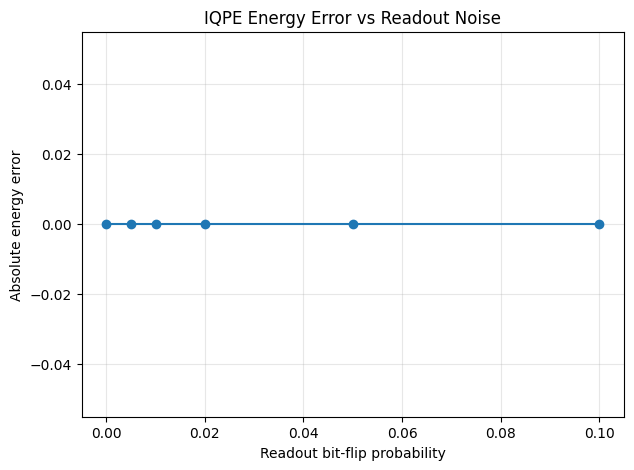

In [16]:
# Plot: readout error
plt.figure(figsize=(7, 5))
plt.plot(readout_levels, readout_errors, marker="o")
plt.xlabel("Readout bit-flip probability")
plt.ylabel("Absolute energy error")
plt.title("IQPE Energy Error vs Readout Noise")
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
# Example
combined = run_noisy_iqpe(
    p_depol=0.01,
    p_readout=0.02,
    shots=5000,
    n_bits=4,
    verbose=True
)

print("COMBINED NOISE")
print("Bits:", combined["bits"])
print("Phase:", combined["phase"])
print("Recovered energy:", combined["energy"])
print("Exact energy:", eigvals[0])
print("Absolute error:", combined["error"])


Iteration k=3: bit=0, P(1)=0.0516, feedback=-0.000000
Iteration k=2: bit=1, P(1)=0.9468, feedback=-0.785398
Iteration k=1: bit=1, P(1)=0.8086, feedback=-1.178097
Iteration k=0: bit=0, P(1)=0.3386, feedback=-1.178097
COMBINED NOISE
Bits: [0 1 1 0]
Phase: 0.375
Recovered energy: -3.0
Exact energy: -3.0
Absolute error: 0.0
